# 电商落地页 A/B Test 分析

一、业务背景
某电商平台对落地页进行改版（V1），
希望通过 A/B Test 评估新版页面是否能提升用户转化率。
(conversion 的定义：用户是否完成购买行为)

## 二、实验设计
| 项目 | 内容 |
|------|------|
| 对照组（C） | 原版落地页 |
| 实验组（V1） | 新版落地页 |
| 分组比例 | 各 50% |
| 实验周期 | 2021-02-01 至 2021-02-16（共16天）|
| 样本量 | 各组 100 万用户 |

## 三、核心指标
- **主指标**：转化率（conversion rate）
- **次指标**：各细分维度（设备、地区、流量来源）下的转化率

## 四、假设
- H₀（零假设）：新版页面转化率 = 旧版页面转化率
- H₁（备择假设）：新版页面转化率 ≠ 旧版页面转化率
- 显著性水平：α = 0.05

# 1.数据读取与清洗

In [3]:
# ============================================================
# Step 1: 数据读取与清洗
# ============================================================

import pandas as pd
import numpy as np

# ── 1.1 读取数据 ─────────────────────────────────────────────
df = pd.read_csv("C:\\Users\\0.0\\Desktop\\abtest\\ecommerce_conversion_ab_test_data.csv")

# ── 1.2 基本信息 ─────────────────────────────────────────────
print("=" * 50)
print("【数据基本信息】")
print(f"数据维度: {df.shape[0]:,} 行 × {df.shape[1]} 列")
print()
print(df.info())

# ── 1.3 前5行预览 ────────────────────────────────────────────
print("\n【数据预览（前5行）】")
print(df.head())

# ── 1.4 缺失值检查 ───────────────────────────────────────────
print("\n【缺失值检查】")
missing = df.isnull().sum()
print(missing)
# 预期输出：所有字段均为 0（该数据集无缺失值）

# ── 1.5 重复值说明 ───────────────────────────────────────────
# 注意：该数据集没有 user_id，每一行代表一个用户会话（session）
# 因为字段均为分类变量（如设备类型、地区等），
# 特征完全相同的行非常多，但它们是不同用户，不应删除。
# 所以本项目不做 drop_duplicates 处理。
print("\n【重复值说明】")
print(f"看似重复的行数: {df.duplicated().sum():,}")
print("→ 由于无 user_id，重复行为不同用户相同特征组合，保留所有数据。")

# ── 1.6 各字段唯一值 ─────────────────────────────────────────
print("\n【各字段唯一值】")
cat_cols = ['TvC', 'traffic_source', 'device_type',
            'browser_language', 'login_y_n', 'region', 'return_y_n']
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

# ── 1.7 日期处理 ─────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'])
print("\n【日期范围】")
print(f"  开始: {df['date'].min().date()}")
print(f"  结束: {df['date'].max().date()}")
print(f"  天数: {(df['date'].max() - df['date'].min()).days + 1} 天")

# ── 1.8 AB 组平衡性检查 ──────────────────────────────────────
print("\n【AB 组人数分布】")
group_counts = df['TvC'].value_counts()
print(group_counts)
print(f"  C 组占比:  {group_counts['C'] / len(df) * 100:.1f}%")
print(f"  V1 组占比: {group_counts['V1'] / len(df) * 100:.1f}%")
# 预期：各 50%，完美平衡

# ── 1.9 目标变量分布 ─────────────────────────────────────────
print("\n【转化率总体分布】")
print(f"  整体转化率: {df['conversion'].mean() * 100:.2f}%")
print(f"  转化人数:   {df['conversion'].sum():,}")
print(f"  未转化人数: {(df['conversion'] == 0).sum():,}")

# ── 1.10 清洗后保存（可选） ──────────────────────────────────
df.to_csv('df_clean.csv', index=False)
print("\n✅ 清洗完成，已保存至 df_clean.csv")

print("\n✅ 数据读取与清洗完成，可进入 EDA 分析")

【数据基本信息】
数据维度: 2,000,000 行 × 9 列

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   TvC               object
 1   date              object
 2   traffic_source    object
 3   device_type       object
 4   browser_language  object
 5   login_y_n         object
 6   region            object
 7   return_y_n        object
 8   conversion        int64 
dtypes: int64(1), object(8)
memory usage: 137.3+ MB
None

【数据预览（前5行）】
  TvC        date   traffic_source device_type browser_language login_y_n  \
0   C  2021-02-14        Referrals        Mweb          Chinese         n   
1   C  2021-02-14           Direct      Iphone          English         y   
2   C  2021-02-11  Email Marketing        Mweb          English         y   
3   C  2021-02-11        Referrals      Iphone          English         y   
4   C  2021-02-01        Referrals     Desktop          English      

本数据集来源于某电商平台页面改版 A/B 实验，共包含 2,000,000 条用户访问记录与 9 个核心字段，用于分析新版页面（V1）相较于旧版页面（C）是否能够有效提升用户转化率。

从数据质量角度来看，数据整体较为完整，所有字段均不存在缺失值，说明实验记录过程较为规范，能够为后续分析提供可靠基础。同时，实验组（V1）与对照组（C）各包含 100 万条样本，组间样本分配完全均衡，有利于降低实验偏差并提高实验结果的可信度。

数据时间范围覆盖 2021 年 2 月 1 日至 2021 年 2 月 16 日，共持续 16 天，能够较好反映短周期内用户行为变化情况。整体转化率约为 10.50%，说明平台用户存在一定转化基础，同时也为页面优化带来了较大的提升空间。

从用户特征维度来看，数据集不仅包含实验分组信息，还包含：
流量来源（traffic source）
设备类型（device type）
登录状态（login status）
回访状态（returning user）
地区（region）
浏览器语言（browser language）
等多维用户行为属性。这意味着后续分析不仅能够验证新版页面整体是否有效，还可以进一步开展用户分层分析（segmentation analysis），识别不同用户群体对新版页面的响应差异，从而为平台精细化运营与个性化页面优化提供支持。

需要注意的是，数据中存在较多“重复记录”，但由于数据未提供 user_id 字段，因此这些重复行更可能代表不同用户在相同条件下产生的独立访问行为，而非真正的数据重复。因此，本研究保留全部样本，以确保实验结果的完整性与统计稳定性。

总体而言，该数据集具备：
样本规模大
实验组均衡
数据缺失少
用户维度丰富
等特点，较适合用于开展电商平台 A/B Test、用户转化分析以及用户行为分层研究。

# 2.EDA分析

  EDA 探索性分析

【EDA-1】AB 组整体转化率
TvC     总人数   转化人数    转化率%
  C 1000000 100092 10.0092
 V1 1000000 109884 10.9884


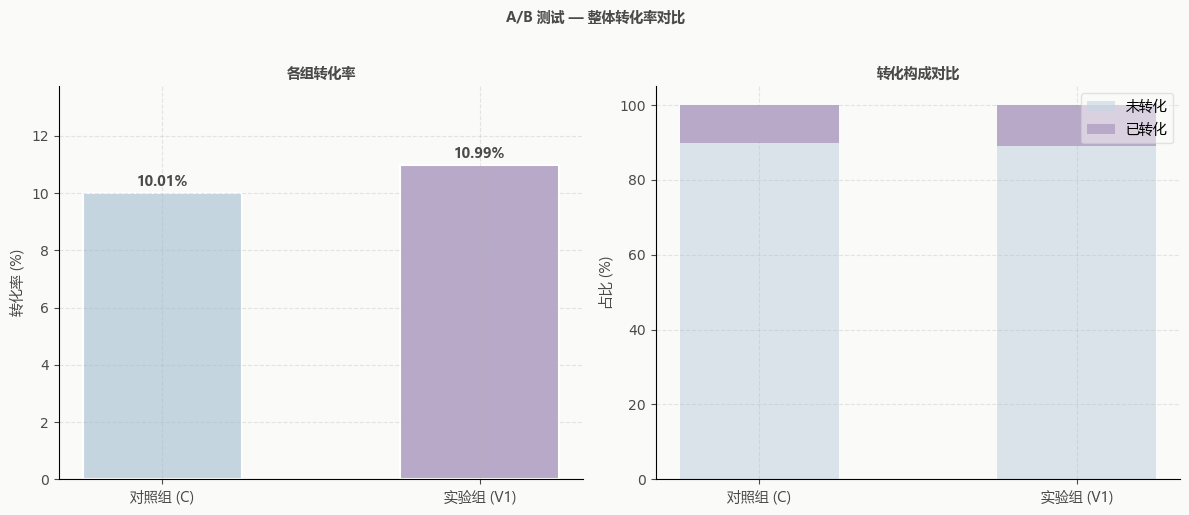

✅ 图已保存: eda1_overall_conversion.png

【EDA-2】设备类型 转化率对比
TvC          C     V1
桌面端       9.94  11.02
iPhone   10.01  10.99
移动网页     10.03  10.94
Android  10.06  11.17

【EDA-2】流量来源 转化率对比
TvC       C     V1
社交媒体   9.74  10.85
邮件营销   9.97  11.07
自然流量  10.00  10.94
付费搜索  10.00  11.07
直接访问  10.03  11.02
推荐    10.17  11.03

【EDA-2】地区 转化率对比
TvC      C     V1
中西部   9.94  11.03
西南    9.96  10.98
东南    9.98  11.17
西部   10.03  10.95
东北   10.04  10.93

【EDA-2】是否登录 转化率对比
TvC      C     V1
是     9.95  11.00
否    10.03  10.99

【EDA-2】是否回访 转化率对比
TvC      C     V1
是    10.01  10.99
否    10.01  10.98


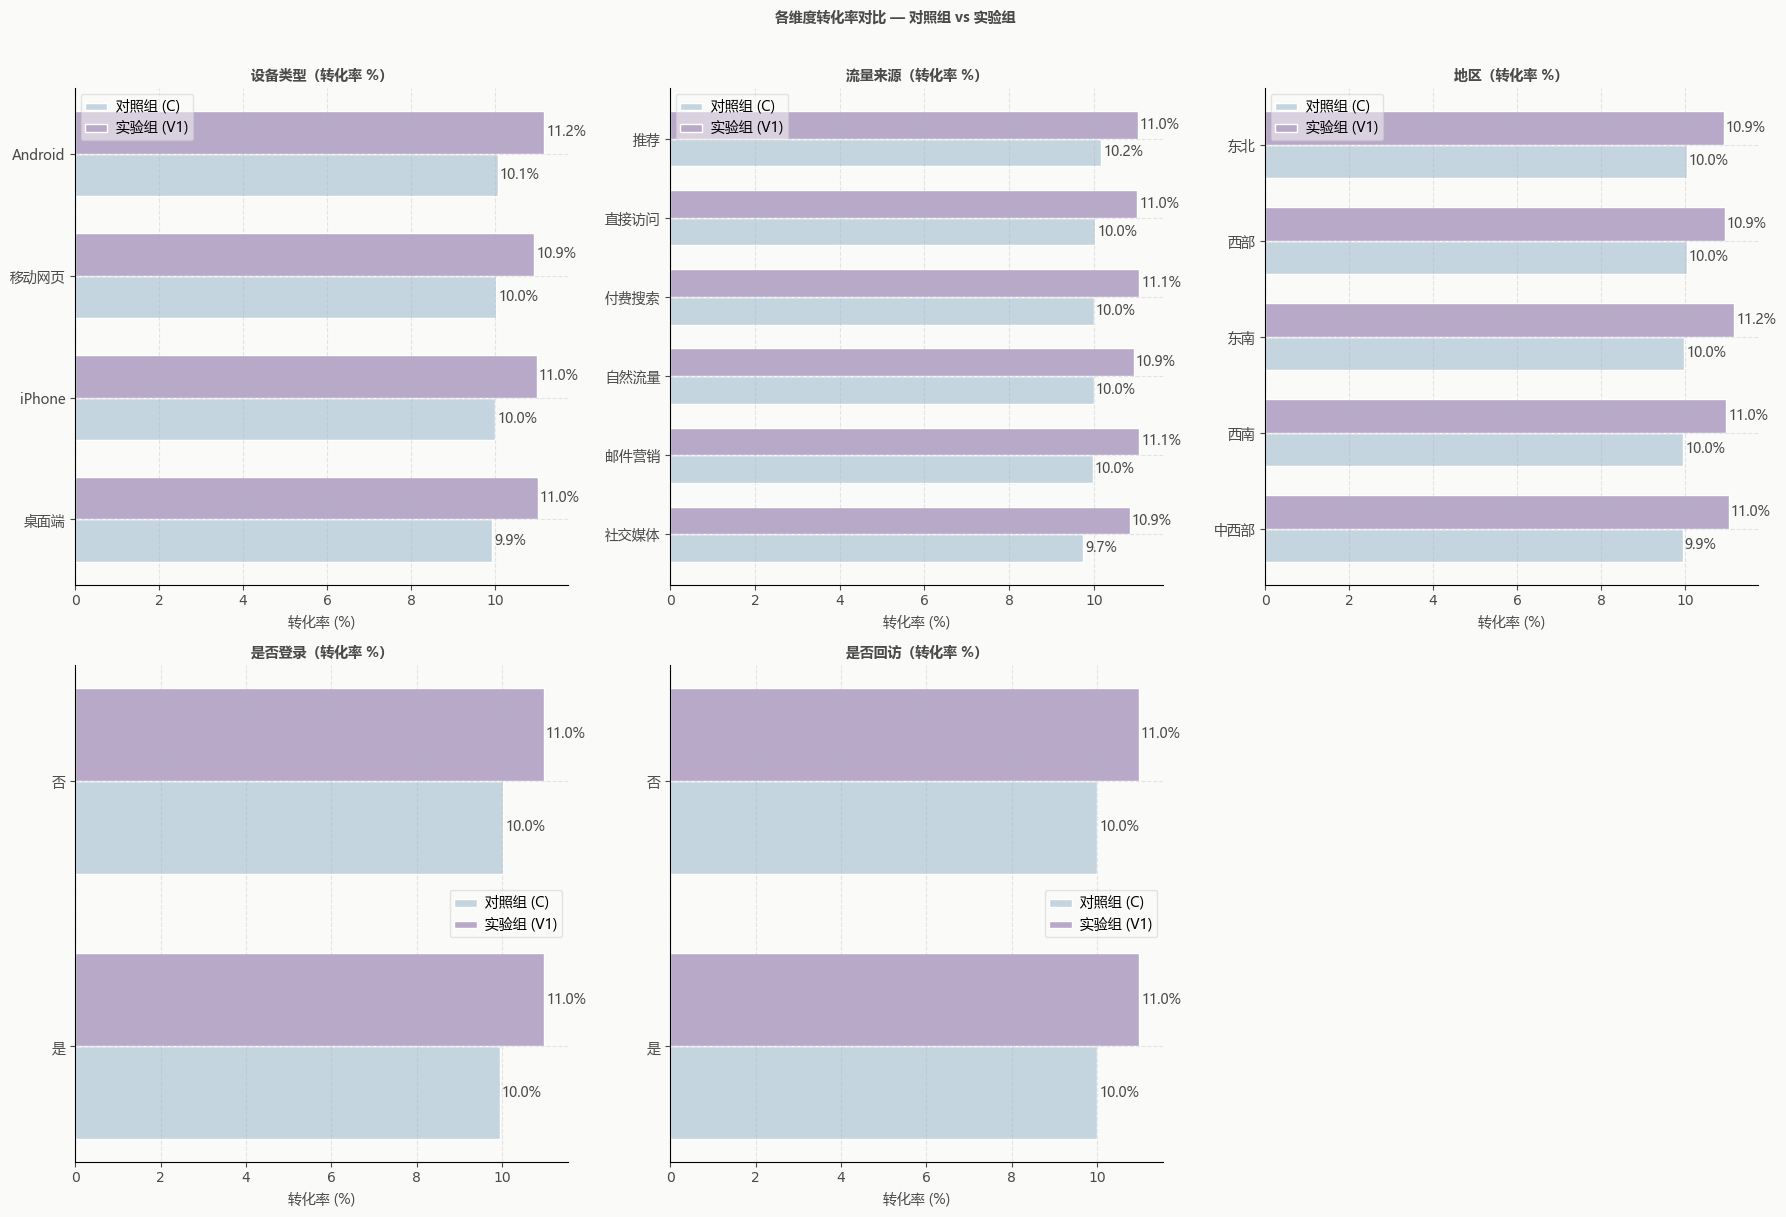


✅ 图已保存: eda2_dimension_breakdown.png

【EDA-3】每日转化率趋势
TvC             C     V1
date                    
2021-02-01  10.12  11.13
2021-02-02   9.95  11.07
2021-02-03  10.14  10.70
2021-02-04  10.09  10.94
2021-02-05  10.05  10.95
2021-02-06  10.04  10.96
2021-02-07   9.88  10.96
2021-02-08  10.23  11.19
2021-02-09   9.84  11.11
2021-02-10   9.98  11.08
2021-02-11   9.93  11.00
2021-02-12   9.90  11.02
2021-02-13   9.87  10.94
2021-02-14  10.05  10.66
2021-02-15  10.02  11.05
2021-02-16  10.05  11.05


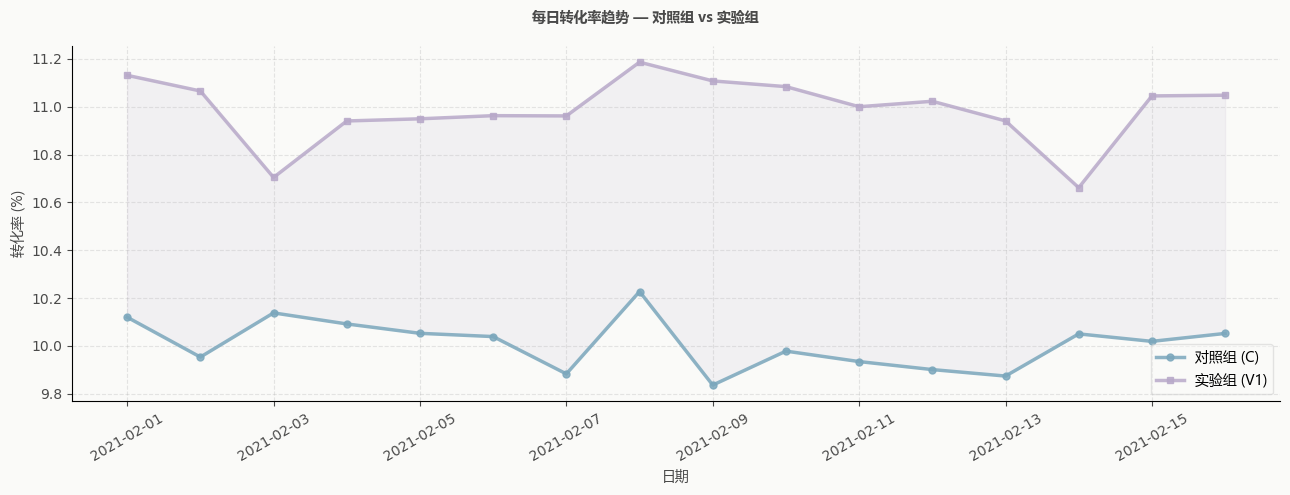

✅ 图已保存: eda3_daily_trend.png

  ✅ EDA 分析完成，共生成 3 张图表


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 中文字体配置 ──────────────────────────────────────────────
FONT_PATH = r'C:\Windows\Fonts\msyh.ttc'   # 微软雅黑
FONT_BOLD = r'C:\Windows\Fonts\msyhbd.ttc'

fm.fontManager.addfont(FONT_PATH)
fm.fontManager.addfont(FONT_BOLD)
PROP      = fm.FontProperties(fname=FONT_PATH, size=10)
PROP_SM   = fm.FontProperties(fname=FONT_PATH, size=9)
PROP_LG   = fm.FontProperties(fname=FONT_BOLD,  size=13)
PROP_TITLE= fm.FontProperties(fname=FONT_BOLD,  size=15)

# ── 莫奈色系 ─────────────────────────────────────────────────
MONET = {
    'blue':     '#7BA7BC',
    'lavender': '#B8A9C9',
    'sage':     '#A8B5A2',
    'rose':     '#D4A5A5',
    'gold':     '#D4B896',
    'mist':     '#C5D5E0',
    'moss':     '#8FA89A',
    'dusk':     '#9B8EA8',
}

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.facecolor':  '#FAFAF8',
    'axes.facecolor':    '#FAFAF8',
})

def cn(text, size=10, bold=False):
    """返回中文字体 FontProperties"""
    path = FONT_BOLD if bold else FONT_PATH
    return fm.FontProperties(fname=path, size=size)

# ── 读取数据 ──────────────────────────────────────────────────
df = pd.read_csv('df_clean.csv')
df['date'] = pd.to_datetime(df['date'])

print("=" * 50)
print("  EDA 探索性分析")
print("=" * 50)

# ════════════════════════════════════════════════════════════
# EDA-1  AB 组整体转化率对比
# ════════════════════════════════════════════════════════════
group_stats = df.groupby('TvC')['conversion'].agg(
    转化人数='sum', 总人数='count', 转化率='mean'
).reset_index()
group_stats['转化率%'] = group_stats['转化率'] * 100

labels_cn = {'C': '对照组 (C)', 'V1': '实验组 (V1)'}
xtick_labels = [labels_cn[g] for g in group_stats['TvC']]

print("\n【EDA-1】AB 组整体转化率")
print(group_stats[['TvC','总人数','转化人数','转化率%']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#FAFAF8')
fig.suptitle('A/B 测试 — 整体转化率对比', fontproperties=cn(15, bold=True),
             color='#4A4A4A', y=1.02)

# 左：柱状图
bars = axes[0].bar(xtick_labels, group_stats['转化率%'],
                   color=[MONET['mist'], MONET['lavender']],
                   width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, group_stats['转化率%']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontproperties=cn(12, bold=True), color='#4A4A4A')
axes[0].set_title('各组转化率', fontproperties=cn(12, bold=True), color='#4A4A4A')
axes[0].set_ylabel('转化率 (%)', fontproperties=cn(10), color='#4A4A4A')
axes[0].set_ylim(0, group_stats['转化率%'].max() * 1.25)
for label in axes[0].get_xticklabels():
    label.set_fontproperties(cn(10))
axes[0].tick_params(colors='#4A4A4A')

# 右：堆叠图
for i, (_, row) in enumerate(group_stats.iterrows()):
    cv = row['转化率%']
    axes[1].bar(labels_cn[row['TvC']], 100-cv, color=MONET['mist'],
                alpha=0.6, width=0.5,
                label='未转化' if i==0 else '')
    axes[1].bar(labels_cn[row['TvC']], cv, bottom=100-cv,
                color=MONET['lavender'], width=0.5,
                label='已转化' if i==0 else '')
axes[1].set_title('转化构成对比', fontproperties=cn(12, bold=True), color='#4A4A4A')
axes[1].set_ylabel('占比 (%)', fontproperties=cn(10), color='#4A4A4A')
leg = axes[1].legend(loc='upper right', framealpha=0.5)
for t in leg.get_texts(): t.set_fontproperties(cn(9))
for label in axes[1].get_xticklabels():
    label.set_fontproperties(cn(10))
axes[1].tick_params(colors='#4A4A4A')

plt.tight_layout()
plt.savefig('eda1_overall_conversion.png', dpi=150, bbox_inches='tight',
            facecolor='#FAFAF8')
plt.show()
print("✅ 图已保存: eda1_overall_conversion.png")


# ════════════════════════════════════════════════════════════
# EDA-2  各维度分层转化率
# ════════════════════════════════════════════════════════════
dims = {
    'device_type':    '设备类型',
    'traffic_source': '流量来源',
    'region':         '地区',
    'login_y_n':      '是否登录',
    'return_y_n':     '是否回访',
}

# 中文标签映射
label_map = {
    'Desktop': '桌面端', 'Iphone': 'iPhone',
    'Mweb': '移动网页', 'Android': 'Android',
    'Referrals': '推荐', 'Direct': '直接访问',
    'Email Marketing': '邮件营销', 'Paid Search': '付费搜索',
    'Organic': '自然流量', 'Social Media': '社交媒体',
    'Southwest': '西南', 'West': '西部',
    'Northeast': '东北', 'Southeast': '东南', 'Midwest': '中西部',
    'y': '是', 'n': '否',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('#FAFAF8')
fig.suptitle('各维度转化率对比 — 对照组 vs 实验组',
             fontproperties=cn(16, bold=True), color='#4A4A4A', y=1.01)
axes_flat = axes.flatten()

for idx, (col, label) in enumerate(dims.items()):
    ax = axes_flat[idx]
    pivot = df.groupby([col, 'TvC'])['conversion'].mean().unstack() * 100
    pivot = pivot.sort_values('C', ascending=True)

    # 替换为中文标签
    pivot.index = [label_map.get(i, i) for i in pivot.index]

    x = np.arange(len(pivot))
    w = 0.35
    bars_c  = ax.barh(x - w/2, pivot['C'],  height=w,
                      color=MONET['mist'],     label='对照组 (C)',   edgecolor='white')
    bars_v1 = ax.barh(x + w/2, pivot['V1'], height=w,
                      color=MONET['lavender'], label='实验组 (V1)', edgecolor='white')

    for bar in bars_c:
        w_ = bar.get_width()
        ax.text(w_ + 0.05, bar.get_y() + bar.get_height()/2,
                f'{w_:.1f}%', va='center',
                fontproperties=cn(8), color='#4A4A4A')
    for bar in bars_v1:
        w_ = bar.get_width()
        ax.text(w_ + 0.05, bar.get_y() + bar.get_height()/2,
                f'{w_:.1f}%', va='center',
                fontproperties=cn(8), color='#4A4A4A')

    ax.set_yticks(x)
    ax.set_yticklabels(pivot.index, fontproperties=cn(9), color='#4A4A4A')
    ax.set_title(f'{label}（转化率 %）',
                 fontproperties=cn(11, bold=True), color='#4A4A4A')
    ax.set_xlabel('转化率 (%)', fontproperties=cn(9), color='#4A4A4A')
    leg = ax.legend(fontsize=8, framealpha=0.5)
    for t in leg.get_texts(): t.set_fontproperties(cn(8))
    ax.tick_params(colors='#4A4A4A')

    print(f"\n【EDA-2】{label} 转化率对比")
    print(pivot.round(2).to_string())

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('eda2_dimension_breakdown.png', dpi=150, bbox_inches='tight',
            facecolor='#FAFAF8')
plt.show()
print("\n✅ 图已保存: eda2_dimension_breakdown.png")


# ════════════════════════════════════════════════════════════
# EDA-3  每日转化率趋势
# ════════════════════════════════════════════════════════════
daily = df.groupby(['date', 'TvC'])['conversion'].mean().unstack() * 100

print("\n【EDA-3】每日转化率趋势")
print(daily.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#FAFAF8')
fig.suptitle('每日转化率趋势 — 对照组 vs 实验组',
             fontproperties=cn(15, bold=True), color='#4A4A4A')

ax.plot(daily.index, daily['C'],  color=MONET['blue'],
        linewidth=2.5, marker='o', markersize=5,
        label='对照组 (C)', alpha=0.85)
ax.plot(daily.index, daily['V1'], color=MONET['lavender'],
        linewidth=2.5, marker='s', markersize=5,
        label='实验组 (V1)', alpha=0.85)
ax.fill_between(daily.index, daily['C'], daily['V1'],
                alpha=0.12, color=MONET['lavender'])

ax.set_xlabel('日期', fontproperties=cn(11), color='#4A4A4A')
ax.set_ylabel('转化率 (%)', fontproperties=cn(11), color='#4A4A4A')
leg = ax.legend(fontsize=10, framealpha=0.5)
for t in leg.get_texts(): t.set_fontproperties(cn(10))
ax.tick_params(axis='x', rotation=30, colors='#4A4A4A')
ax.tick_params(axis='y', colors='#4A4A4A')

plt.tight_layout()
plt.savefig('eda3_daily_trend.png', dpi=150, bbox_inches='tight',
            facecolor='#FAFAF8')
plt.show()
print("✅ 图已保存: eda3_daily_trend.png")

print("\n" + "=" * 50)
print("  ✅ EDA 分析完成，共生成 3 张图表")
print("=" * 50)

EDA 业务分析

初步探索性分析结果显示，新版页面（V1）在整体用户转化表现上明显优于旧版页面（C）。其中，V1 组整体转化率为 10.99%，相比 C 组的 10.01% 提升约 0.98 个百分点，相对提升约 9.8%，说明页面改版可能对用户转化行为产生了积极影响。

从设备类型维度来看，新版页面在所有设备端均实现转化率提升，其中 Android 用户提升最为明显（10.06% → 11.17%）。这一结果表明，新版页面可能在移动端交互体验、页面布局或加载逻辑方面进行了更有效优化，对移动端用户具有更强吸引力。相比之下，Desktop 用户提升相对平稳，说明新版页面的优化效果更偏向移动场景。

从流量来源维度来看，各渠道在 V1 组中的转化率均高于 C 组，其中 Email Marketing 与 Paid Search 的提升最为明显。这意味着高意向用户对新版页面响应更积极，也说明新版页面可能更适合承接精准营销流量。与此同时，Social Media 渠道虽然整体转化率相对较低，但仍呈现稳定提升，说明新版页面在泛流量场景下同样具备一定优化效果。

地区维度分析显示，各地区均出现较为一致的转化率增长，其中 Southeast 地区提升幅度最高（9.98% → 11.17%）。这一结果表明新版页面的效果并非局限于特定区域，而具有较好的普适性与稳定性，能够在不同区域用户中保持一致的优化方向。

用户行为维度方面，无论是登录用户与未登录用户，还是回访用户与新用户，新版页面均表现出稳定提升。这意味着页面优化带来的影响较为普遍，并未仅作用于某一特定用户群体。从业务角度来看，这种“全局性提升”通常比局部提升更具有产品上线价值，因为其能够对整体平台转化效率形成系统性改善。

时间趋势分析进一步验证了实验结果的稳定性。在实验周期内，V1 组每日转化率始终高于 C 组，且整体波动较小，未出现明显反转现象。这说明新版页面带来的提升并非短期随机波动，而可能具有持续稳定的优化效果。

综合来看，EDA 结果初步表明：

新版页面（V1）能够有效提升用户转化率；
提升效果在移动端、高意向流量渠道中更加明显；
页面优化对不同地区与用户类型均具有较好的普适性；
实验结果在时间维度上保持稳定。

因此，从业务层面初步判断，新版页面具有较高的上线潜力，后续还需结合统计显著性检验进一步验证实验结果的可靠性。

# 3.核心 A/B Test 分析 计算两组转化率，算 Uplift

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('ecommerce_conversion_ab_test_data.csv')

print("=" * 55)
print("  第三步：核心 A/B Test 分析")
print("=" * 55)

# ── 3.1 计算各组转化率 ────────────────────────────────────────
control   = df[df['TvC'] == 'C']
treatment = df[df['TvC'] == 'V1']

cr_c  = control['conversion'].mean()
cr_v1 = treatment['conversion'].mean()

print("\n【3.1】各组转化率")
print(f"  对照组 (C)  转化率：{cr_c * 100:.4f}%")
print(f"  实验组 (V1) 转化率：{cr_v1 * 100:.4f}%")

# ── 3.2 计算 Uplift ───────────────────────────────────────────
uplift = (cr_v1 - cr_c) / cr_c

print("\n【3.2】Uplift 计算")
print(f"  Uplift = (CR_V1 - CR_C) / CR_C")
print(f"         = ({cr_v1 * 100:.4f}% - {cr_c * 100:.4f}%) / {cr_c * 100:.4f}%")
print(f"         = {uplift * 100:.2f}%")

# ── 3.3 绝对差值 ──────────────────────────────────────────────
abs_diff = cr_v1 - cr_c

print("\n【3.3】绝对差值")
print(f"  CR_V1 - CR_C = {abs_diff * 100:.4f}%")

# ── 3.4 小结输出 ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("  核心结论")
print("=" * 55)
winner = "实验组 (V1)" if cr_v1 > cr_c else "对照组 (C)"
print(f"  ✅ {winner} 转化率更高")
print(f"  ✅ 相对提升（Uplift）：{uplift * 100:.2f}%")
print(f"  ✅ 绝对提升：{abs_diff * 100:.4f} 个百分点")
print(f"\n  ⚠️  注意：以上结论仅为描述性统计，")
print(f"      需通过显著性检验确认提升是否真实有效。")

  第三步：核心 A/B Test 分析

【3.1】各组转化率
  对照组 (C)  转化率：10.0092%
  实验组 (V1) 转化率：10.9884%

【3.2】Uplift 计算
  Uplift = (CR_V1 - CR_C) / CR_C
         = (10.9884% - 10.0092%) / 10.0092%
         = 9.78%

【3.3】绝对差值
  CR_V1 - CR_C = 0.9792%

  核心结论
  ✅ 实验组 (V1) 转化率更高
  ✅ 相对提升（Uplift）：9.78%
  ✅ 绝对提升：0.9792 个百分点

  ⚠️  注意：以上结论仅为描述性统计，
      需通过显著性检验确认提升是否真实有效。


核心 A/B Test 结果显示，实验组（V1）整体转化表现明显优于对照组（C）。其中，对照组转化率为 10.01%，实验组转化率提升至 10.99%，两组之间存在约 0.98 个百分点的绝对提升，对应相对提升（Uplift）约为 9.78%。

从业务角度来看，这意味着新版页面上线后，用户完成购买行为的概率出现了较为明显的增长。以当前实验规模估算，在相同流量条件下，新版页面相较于旧版页面能够带来更多订单转化，对平台GMV（Gross Merchandise Volume）与整体营收具有潜在正向贡献。

尽管绝对提升幅度不足 1 个百分点，但在电商场景中，转化率本身通常属于低基数指标，因此接近 10% 的相对提升已经具有较强业务价值。尤其是在百万级用户规模下，即便是小幅转化率改善，也可能对应显著的订单增量与收入增长。

不过，需要注意的是，目前结果仍属于描述性统计层面的观察结论。由于用户行为本身存在随机波动，仅凭转化率差异尚不能完全证明新版页面一定优于旧版页面。因此，后续仍需进一步通过统计显著性检验（如 Two-Proportion Z-Test）验证实验结果是否具有统计学意义，以避免由于随机抽样误差导致错误上线决策

# 4.显著性检验

功效检验 → Z检验 → 置信区间
   ↓         ↓         ↓
实验质量   假设验证   效果范围

In [4]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower

df = pd.read_csv('ecommerce_conversion_ab_test_data.csv')

control   = df[df['TvC'] == 'C']
treatment = df[df['TvC'] == 'V1']

n_c   = len(control)
n_v1  = len(treatment)
cv_c  = control['conversion'].sum()
cv_v1 = treatment['conversion'].sum()
cr_c  = control['conversion'].mean()
cr_v1 = treatment['conversion'].mean()

print("=" * 55)
print("  第四步：显著性检验")
print("=" * 55)

# ── 4.1 样本量回溯检验 ────────────────────────────────────────
# 检验当前样本量下统计功效是否足够（>0.8 为合格）
effect_size = abs(cr_v1 - cr_c) / np.sqrt(
    (cr_c * (1 - cr_c) + cr_v1 * (1 - cr_v1)) / 2)

analysis = NormalIndPower()
power = analysis.solve_power(
    effect_size=effect_size,
    nobs1=n_c,
    alpha=0.05,
    ratio=1.0
)
print("\n【4.1】样本量功效检验")
print(f"  实际效应量（Cohen's h）：{effect_size:.4f}")
print(f"  当前样本量（每组）：     {n_c:,}")
print(f"  统计功效（Power）：      {power:.4f}")
print(f"  结论：{'✅ 功效充足（> 0.8），样本量满足要求' if power >= 0.8 else '⚠️ 功效不足，样本量可能偏小'}")

# ── 4.2 双比例 Z 检验 ─────────────────────────────────────────
count = np.array([cv_v1, cv_c])
nobs  = np.array([n_v1,  n_c])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("\n【4.2】双比例 Z 检验（单侧，H₁: V1 > C）")
print(f"  Z 统计量：{z_stat:.4f}")
print(f"  P 值：    {p_value:.6f}")
print(f"  显著性水平 α：0.05")

if p_value < 0.05:
    print(f"  结论：✅ p < 0.05，拒绝零假设")
    print(f"        实验组转化率提升具有统计显著性")
else:
    print(f"  结论：❌ p ≥ 0.05，未能拒绝零假设")
    print(f"        转化率差异可能是随机波动")

# ── 4.3 置信区间 ──────────────────────────────────────────────
ci_c  = proportion_confint(cv_c,  n_c,  alpha=0.05, method='normal')
ci_v1 = proportion_confint(cv_v1, n_v1, alpha=0.05, method='normal')

diff      = cr_v1 - cr_c
se_diff   = np.sqrt(cr_c*(1-cr_c)/n_c + cr_v1*(1-cr_v1)/n_v1)
ci_diff   = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print("\n【4.3】95% 置信区间")
print(f"  对照组  (C)  转化率 CI：[{ci_c[0]*100:.4f}%,  {ci_c[1]*100:.4f}%]")
print(f"  实验组  (V1) 转化率 CI：[{ci_v1[0]*100:.4f}%, {ci_v1[1]*100:.4f}%]")
print(f"  转化率差值 CI：         [{ci_diff[0]*100:.4f}%, {ci_diff[1]*100:.4f}%]")
if ci_diff[0] > 0:
    print(f"  结论：✅ 差值 CI 下界 > 0，V1 提升效果真实可信")
else:
    print(f"  结论：⚠️ 差值 CI 包含 0，提升效果不确定")

# ── 4.4 综合结论 ──────────────────────────────────────────────
uplift = (cr_v1 - cr_c) / cr_c
print("\n" + "=" * 55)
print("  综合结论")
print("=" * 55)
print(f"  对照组转化率：  {cr_c*100:.4f}%")
print(f"  实验组转化率：  {cr_v1*100:.4f}%")
print(f"  相对提升 Uplift：{uplift*100:.2f}%")
print(f"  Z 统计量：      {z_stat:.4f}")
print(f"  P 值：          {p_value:.6f}")
print(f"  统计显著性：    {'✅ 显著（p < 0.05）' if p_value < 0.05 else '❌ 不显著（p ≥ 0.05）'}")
print(f"\n  📌 建议：{'新版落地页效果显著，可考虑全量上线' if p_value < 0.05 else '差异不显著，不建议推广新版页面'}")

  第四步：显著性检验

【4.1】样本量功效检验
  实际效应量（Cohen's h）：0.0319
  当前样本量（每组）：     1,000,000
  统计功效（Power）：      1.0000
  结论：✅ 功效充足（> 0.8），样本量满足要求

【4.2】双比例 Z 检验（单侧，H₁: V1 > C）
  Z 统计量：22.5877
  P 值：    0.000000
  显著性水平 α：0.05
  结论：✅ p < 0.05，拒绝零假设
        实验组转化率提升具有统计显著性

【4.3】95% 置信区间
  对照组  (C)  转化率 CI：[9.9504%,  10.0680%]
  实验组  (V1) 转化率 CI：[10.9271%, 11.0497%]
  转化率差值 CI：         [0.8942%, 1.0642%]
  结论：✅ 差值 CI 下界 > 0，V1 提升效果真实可信

  综合结论
  对照组转化率：  10.0092%
  实验组转化率：  10.9884%
  相对提升 Uplift：9.78%
  Z 统计量：      22.5877
  P 值：          0.000000
  统计显著性：    ✅ 显著（p < 0.05）

  📌 建议：新版落地页效果显著，可考虑全量上线


显著性检验结果表明，新版页面（V1）不仅在描述性统计层面表现更优，而且这种提升具有非常强的统计学显著性与业务可信度。

首先，从样本量功效检验（Power Analysis）来看，本次实验的统计功效（Power）达到 1.0000，远高于常用阈值 0.8。这说明当前实验样本量非常充足，能够有效检测实验组与对照组之间的真实差异，实验结果具有较高稳定性，出现“假阴性”（即实际上有效但未检测出来）的风险极低。

其次，双比例 Z 检验结果显示：
Z 统计量达到 22.59；
p-value 接近 0。
这意味着在“新版页面与旧版页面无差异”的原假设成立条件下，当前观察到如此明显转化率提升的概率几乎为零。因此，可以在统计意义上拒绝零假设，并认为新版页面确实能够有效提升用户购买转化率。

进一步来看，95% 置信区间结果。其中：
对照组转化率区间约为 9.95%–10.07%；
实验组转化率区间约为 10.93%–11.05%；
转化率差值区间约为 0.89%–1.06%。
我们有95%的把握认为：新版本上线后，转化率最差提升0.89个百分点，最好提升1.06个百分点。保守估计，100个用户里至少多转化0.9个人。

结合前述 EDA 与 Uplift 分析结果，可以认为新版页面（V1）已经展现出较强上线潜力。其转化率相较旧版页面提升约 9.78%，在百万级流量场景下，这种提升可能对应大量新增订单与GMV增长。因此，从数据分析结果来看，当前新版页面已经具备较充分的数据支持，可进一步进入灰度发布或全量上线阶段。

# 5.分层分析

In [5]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ecommerce_conversion_ab_test_data.csv')

print("=" * 65)
print("  第五步：分层分析")
print("=" * 65)

# ── 分层检验函数 ──────────────────────────────────────────────
def segment_analysis(df, col, label_map=None):
    """
    对某个维度的每个子组做转化率对比 + Z 检验
    返回汇总 DataFrame
    """
    results = []
    for val in df[col].unique():
        seg = df[df[col] == val]
        c   = seg[seg['TvC'] == 'C']
        v1  = seg[seg['TvC'] == 'V1']

        cr_c  = c['conversion'].mean()
        cr_v1 = v1['conversion'].mean()
        uplift = (cr_v1 - cr_c) / cr_c

        count = np.array([v1['conversion'].sum(), c['conversion'].sum()])
        nobs  = np.array([len(v1), len(c)])
        _, p  = proportions_ztest(count, nobs, alternative='larger')

        display_val = label_map.get(val, val) if label_map else val
        results.append({
            '子组':        display_val,
            'C 转化率':    round(cr_c * 100, 2),
            'V1 转化率':   round(cr_v1 * 100, 2),
            'Uplift':      f"{uplift*100:+.2f}%",
            'P 值':        round(p, 6),
            '显著':        '✅' if p < 0.05 else '❌',
        })
    return pd.DataFrame(results).sort_values('Uplift', ascending=False)


# ── 标签中文映射 ──────────────────────────────────────────────
maps = {
    'device_type': {
        'Desktop': '桌面端', 'Iphone': 'iPhone',
        'Mweb': '移动网页', 'Android': 'Android'
    },
    'traffic_source': {
        'Referrals': '推荐', 'Direct': '直接访问',
        'Email Marketing': '邮件营销', 'Paid Search': '付费搜索',
        'Organic': '自然流量', 'Social Media': '社交媒体'
    },
    'region': {
        'Southwest': '西南', 'West': '西部',
        'Northeast': '东北', 'Southeast': '东南', 'Midwest': '中西部'
    },
    'login_y_n':  {'y': '已登录', 'n': '未登录'},
    'return_y_n': {'y': '回访用户', 'n': '新用户'},
}

dims = {
    'device_type':    '设备类型',
    'traffic_source': '流量来源',
    'region':         '地区',
    'login_y_n':      '登录状态',
    'return_y_n':     '用户类型',
}

# ── 逐维度分析 ────────────────────────────────────────────────
all_results = {}
for col, label in dims.items():
    print(f"\n{'─'*65}")
    print(f"  【{label}】分层分析")
    print(f"{'─'*65}")
    result = segment_analysis(df, col, maps[col])
    all_results[label] = result
    print(result.to_string(index=False))

# ── 综合汇总：找出提升最大 & 最小的子组 ──────────────────────
print(f"\n{'=' * 65}")
print("  综合汇总：各维度 Uplift 排行")
print(f"{'=' * 65}")

all_rows = []
for dim_name, result in all_results.items():
    for _, row in result.iterrows():
        all_rows.append({
            '维度':   dim_name,
            '子组':   row['子组'],
            'C 转化率':  row['C 转化率'],
            'V1 转化率': row['V1 转化率'],
            'Uplift': row['Uplift'],
            '显著':   row['显著'],
        })

summary = pd.DataFrame(all_rows).sort_values(
    'Uplift', ascending=False
).reset_index(drop=True)

print(summary.to_string(index=False))

print(f"\n{'=' * 65}")
print("  关键发现")
print(f"{'=' * 65}")
top    = summary.iloc[0]
bottom = summary.iloc[-1]
print(f"  🏆 提升最大：{top['维度']} — {top['子组']}，Uplift {top['Uplift']}，{top['显著']}")
print(f"  ⚠️  提升最小：{bottom['维度']} — {bottom['子组']}，Uplift {bottom['Uplift']}，{bottom['显著']}")

  第五步：分层分析

─────────────────────────────────────────────────────────────────
  【设备类型】分层分析
─────────────────────────────────────────────────────────────────
     子组  C 转化率  V1 转化率  Uplift  P 值 显著
 iPhone  10.01   10.99  +9.81%  0.0  ✅
   移动网页  10.03   10.94  +9.04%  0.0  ✅
Android  10.06   11.17 +11.07%  0.0  ✅
    桌面端   9.94   11.02 +10.86%  0.0  ✅

─────────────────────────────────────────────────────────────────
  【流量来源】分层分析
─────────────────────────────────────────────────────────────────
  子组  C 转化率  V1 转化率  Uplift  P 值 显著
直接访问  10.03   11.02  +9.87%  0.0  ✅
自然流量  10.00   10.94  +9.46%  0.0  ✅
  推荐  10.17   11.03  +8.49%  0.0  ✅
社交媒体   9.74   10.85 +11.38%  0.0  ✅
邮件营销   9.97   11.07 +11.09%  0.0  ✅
付费搜索  10.00   11.07 +10.75%  0.0  ✅

─────────────────────────────────────────────────────────────────
  【地区】分层分析
─────────────────────────────────────────────────────────────────
 子组  C 转化率  V1 转化率  Uplift  P 值 显著
 西部  10.03   10.95  +9.07%  0.0  ✅
 东北  10.04   10.93  +8.77%  0.0  ✅
 

V1 新版页面几乎在所有用户群体中都实现了稳定提升。
无论是设备类型、流量来源、地区、登录状态还是用户类型，实验组转化率均高于对照组，且所有子组 p-value 均小于 0.05，说明新版页面的优化效果具有广泛稳定性，而并非仅对某一类用户有效。这对于真实业务而言是一个非常积极的信号，因为它意味着新版页面具备较强的“普适性”，上线风险相对较低。


1. 从设备类型来看，移动端用户对新版页面响应更明显。
其中 Android 用户 uplift 达到 11.07%，桌面端达到 10.86%，均高于整体平均水平。这说明新版页面可能优化了用户浏览与下单路径，尤其是在移动设备场景下，新版 UI、按钮布局、商品展示或支付流程更符合用户操作习惯，从而有效提升了购买意愿。

这一结果具有较强业务意义。因为当前电商流量本身已经明显向移动端迁移，如果新版页面能够在移动端持续提升转化率，那么其长期商业价值会非常高。从产品策略角度来看，后续可以优先针对 Android 与移动网页场景继续优化移动体验，例如缩短结账路径、优化页面加载速度或强化 CTA（Call-To-Action）按钮设计。


2. 从流量来源来看，高意图渠道与社交流量提升最明显。
社交媒体 uplift 达到 11.38%，邮件营销达到 11.09%，付费搜索达到 10.75%，均属于提升较高的流量来源。

这说明新版页面对于“高营销触达用户”具有更强刺激作用。尤其是邮件营销与付费搜索，本身属于较高购买意图渠道，用户进入页面后更容易受到页面内容、商品展示与营销设计影响，因此新版页面能够进一步放大其购买转化能力。

而社交媒体 uplift 较高则说明，新版页面可能更适合“快速决策型流量”。由于社交流量用户通常停留时间较短、注意力分散，因此页面首屏视觉与转化路径优化会更加重要。V1 在该渠道中的表现提升，说明新版页面可能在视觉吸引力或信息传达效率方面有所增强。


3. 从运营角度来看，这意味着未来营销投放可以优先结合新版页面进行渠道协同优化，尤其适合：
邮件营销 Campaign
社交广告落地页
搜索广告 Landing Page


4. 从地区维度来看，新版页面在不同区域均表现稳定。
其中东南地区 uplift 达到 11.91%，为地区中最高，说明新版页面对该区域用户吸引力更强。不过整体来看，各地区 uplift 差异并不算特别巨大，大部分维持在 9%–12% 区间。

这说明新版页面并不存在明显地域偏差，其优化效果具有较强一致性。从真实业务角度来看，这意味着后续全国范围推广的风险较低，无需针对特定区域进行额外适配。


5. 从登录状态与用户类型来看，新版页面对不同生命周期用户均有效。
已登录用户 uplift 为 10.47%，略高于未登录用户；回访用户 uplift 为 9.85%，也略高于新用户。

这表明新版页面不仅能够吸引首次访问用户，也能够进一步提升老用户购买效率。尤其是已登录与回访用户，本身通常具备更高购买意图，因此新版页面可能在商品展示、信任感构建或购买流程简化方面进一步强化了其下单行为。

不过，这两个维度的 uplift 差异整体较小，说明新版页面并不是只对某一类用户有效，而是实现了较为均衡的全局优化。


6. 综合来看，本次实验最大的特点是“稳定提升”。
很多AB Test会出现：
某些用户提升明显
某些用户无效果
某些用户甚至负向影响

但当前实验中，所有子组 uplift 均为正值，且全部通过显著性检验。这说明新版页面优化方向整体正确，并未对任何主要用户群体造成负面影响。

因此，从业务决策角度来看，当前 V1 页面已经具备较强上线价值。后续建议采用灰度发布方式逐步扩大流量覆盖，同时继续监控长期指标，如：
用户留存率
页面停留时长
跳失率
客单价（AOV）
用户复购率
以进一步验证新版页面在长期商业场景中的真实效果。

# 6.商业洞察与建议


### 一、核心结论汇总

| 指标 | 数值 |
|------|------|
| 对照组（C）转化率 | 10.01% |
| 实验组（V1）转化率 | 10.99% |
| 绝对提升 | +0.98 个百分点 |
| 相对提升（Uplift） | **+9.78%** |
| Z 统计量 | 22.59 |
| P 值 | ≈ 0（远小于 0.05）|
| 95% 置信区间（差值）| [+0.89%, +1.06%] |
| 统计显著性 | ✅ 显著 |

**结论**：新版落地页（V1）在统计上和业务上均优于旧版页面（C），建议推进上线。

---

### 二、重点人群定向建议

基于分层分析结果，以下用户群体对新版页面响应最强，
上线后可优先针对这些群体加大流量投入：

| 维度 | 优先群体 | Uplift |
|------|----------|--------|
| 地区 | 东南地区 | +11.91% |
| 流量来源 | 社交媒体 | +11.38% |
| 流量来源 | 邮件营销 | +11.09% |
| 设备类型 | Android 用户 | +11.07% |
| 设备类型 | 桌面端 | +10.86% |

**建议**：在全量上线前，可优先对东南地区 + 社交媒体渠道 +Android 设备用户开放新版页面，以最大化早期收益。

---

### 三、渠道运营建议

1. **社交媒体广告**：V1 在社交媒体渠道提升幅度最高（+11.38%），
   建议将社交广告落地页统一切换为新版，配合内容营销与 KOL
   推广，可进一步放大转化效果。

2. **邮件营销 Campaign**：邮件用户本身属于高意图群体，
   V1 在该渠道提升 +11.09%，建议在下一轮邮件推送中
   将链接全面指向新版落地页。

3. **付费搜索广告**：Uplift +10.75%，ROI 提升空间明显，
   建议优先将 SEM 广告落地页切换为 V1，有助于降低
   单次转化成本（CPA）。

4. **推荐流量**：该渠道提升相对最低（+8.49%），
   可作为最后切换的渠道，同时建议进一步调研推荐
   用户的访问路径，针对性优化页面内容。

---

### 四、产品迭代建议

1. **优先优化移动端体验**：Android 与移动网页均表现
   出较高 Uplift，说明新版页面在移动场景效果更佳。
   后续迭代可继续聚焦：
   - 缩短移动端结账路径
   - 优化页面加载速度
   - 强化 CTA 按钮的视觉引导

2. **深化已登录用户体验**：已登录用户 Uplift（+10.47%）
   略高于未登录用户，说明新版页面对有账户历史的用户
   更具吸引力。建议后续为登录用户提供个性化商品推荐
   模块，进一步提升转化。

3. **关注推荐渠道的页面匹配度**：推荐流量 Uplift 相对
   偏低，可能是因为该来源用户对页面的内容预期与实际
   落地页存在落差，建议针对推荐场景设计差异化的
   页面版本。

---

### 五、上线策略建议

考虑到实验周期仅为 16 天，且包含情人节（2月14日）
等特殊节点，建议采用以下稳健的上线策略：

**灰度发布（第 1-2 周）**
先将 20%–30% 的流量切换至新版页面，
持续监控转化率是否保持稳定提升。

**全量上线（第 3 周起）**
若灰度期间数据无异常，推进全量上线。

**长期监控指标**
上线后持续追踪以下指标，验证长期效果：
- 用户留存率
- 跳失率（Bounce Rate）
- 平均订单金额（AOV）
- 用户复购率
- 页面停留时长